# BI-LSTM + PSO - DU BAO GIA CO PHIEU

## Mo hinh: Bidirectional LSTM ket hop voi Particle Swarm Optimization (PSO)
## Dataset: GOOGLE (GOOG) va Vinamilk (VNM)
## Muc tieu: Du bao gia dong cua (Close Price) cua co phieu

---

### Cac ky thuat ap dung:
1. **Bi-LSTM**: Mang LSTM 2 chieu, xu ly chuoi tu ca qua khu va tuong lai
2. **PSO (Particle Swarm Optimization)**: Toi uu hoa sieu tham so cua mo hinh
3. **MinMaxScaler**: Chuan hoa du lieu ve khoang [0, 1]
4. **Sliding Window**: Ky thuat cua so truot de tao tap du lieu train/test
5. **Early Stopping**: Dung som khi mo hinh khong cai thien
6. **Model Checkpoint**: Luu mo hinh tot nhat trong qua trinh huan luyen

In [32]:
# =============================================================================
# CELL 1: IMPORT THU VIEN
# =============================================================================
# Thu vien xu ly du lieu
import pandas as pd
import numpy as np
import math
import os
import json
import warnings
from datetime import datetime

# Thu vien truc quan hoa
import matplotlib.pyplot as plt
import seaborn as sns

# Thu vien tai du lieu chung khoan
import yfinance as yf

# Thu vien Deep Learning (Keras/TensorFlow)
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

# Thu vien tien xu ly va danh gia
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, r2_score

# Thu vien toi uu hoa PSO
import pyswarms as ps

# Tat canh bao khong can thiet
warnings.filterwarnings("ignore")

# Cau hinh hien thi bieu do
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

print("Import thu vien thanh cong!")

Import thu vien thanh cong!


# PHAN 1: CAU HINH VA HANG SO

Dinh nghia cac hang so va cau hinh chung cho toan bo notebook.

In [ ]:
# =============================================================================
# CELL 2: CAU HINH THAM SO CHUNG (V8 - PSO THEO BAI BAO KHOA HOC)
# =============================================================================
#
# THAM KHAO PSO TU CAC BAI BAO:
# 1. Shi & Eberhart (1998): Inertia weight w giam tu 0.9 -> 0.4
# 2. Clerc & Kennedy (2002): c1=c2=2.05, w=0.7298 (constriction factor)
# 3. Bansal et al. (2011): w in [0.4, 0.9], c1=c2=2.0
# 4. LSTM-PSO papers: 20-30 particles, 30-50 iterations
# =============================================================================

# --- 1. Cau hinh thoi gian lay du lieu ---
START_DATE = "2013-07-10"
END_DATE = "2024-11-16"

# --- 2. Cau hinh chia tap du lieu ---
TRAIN_RATIO = 0.8            # Ti le train/test: 80/20
TIME_STEP = 50               # Window size = 50

# --- 3. Cau hinh huan luyen mo hinh ---
EPOCHS = 100                 # So vong lap huan luyen
BATCH_SIZE = 64              # Batch size = 64
PATIENCE = 15                # Patience cho Early Stopping
LEARNING_RATE = 0.001        # Learning rate = 0.001

# --- 4. Cau hinh PSO (Theo Clerc & Kennedy 2002 + thuc nghiem) ---
PSO_PARTICLES = 20           # So particles (20-30 theo cac bai bao)
PSO_ITERATIONS = 20         # So iterations (30-50 theo cac bai bao)
PSO_EPOCHS = 15              # Epochs moi lan train trong PSO
PSO_OPTIONS = {
    'c1': 2.0,               # Cognitive - hoc tu ban than (Bansal 2011)
    'c2': 2.0,               # Social - hoc tu dam (Bansal 2011)
    'w': 0.729               # Inertia weight (Clerc & Kennedy 2002)
}

# --- 5. Duong dan luu tru ---
LOGS_DIR = "../../LOGS/BiLSTM+PSO/"
CHART_DIR = "../../CHART/BiLSTM+PSO/"

os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

print("Cau hinh V8 (PSO theo bai bao khoa hoc) hoan tat!")
print(f"  - Ti le train/test: {TRAIN_RATIO*100:.0f}%/{(1-TRAIN_RATIO)*100:.0f}%")
print(f"  - Window size: {TIME_STEP}, Batch size: {BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"\n  [PSO Config - Clerc & Kennedy 2002 + Bansal 2011]")
print(f"  - Particles: {PSO_PARTICLES}, Iterations: {PSO_ITERATIONS}")
print(f"  - c1 (cognitive): {PSO_OPTIONS['c1']}")
print(f"  - c2 (social): {PSO_OPTIONS['c2']}")
print(f"  - w (inertia): {PSO_OPTIONS['w']}")

Cau hinh V8 (PSO theo bai bao khoa hoc) hoan tat!
  - Ti le train/test: 80%/20%
  - Window size: 50, Batch size: 64
  - Learning rate: 0.001

  [PSO Config - Clerc & Kennedy 2002 + Bansal 2011]
  - Particles: 20, Iterations: 20
  - c1 (cognitive): 2.0
  - c2 (social): 2.0
  - w (inertia): 0.729


In [34]:
# =============================================================================
# CELL 3: HAM TAI DU LIEU TU YAHOO FINANCE HOAC CSV
# =============================================================================

def load_stock_data(ticker, start_date, end_date):
    """
    Tai du lieu co phieu tu Yahoo Finance. Neu that bai, su dung file CSV.
    """
    print(f"Dang tai du lieu {ticker}...")
    
    try:
        raw_data = yf.download(
            ticker, 
            start=start_date, 
            end=end_date, 
            auto_adjust=False, 
            progress=False
        )
        
        # Kiem tra neu khong tai duoc du lieu
        if raw_data.empty or len(raw_data) == 0:
            raise ValueError(f"Khong tai duoc du lieu tu Yahoo Finance cho {ticker}")
        
        if isinstance(raw_data.columns, pd.MultiIndex):
            raw_data.columns = raw_data.columns.droplevel(1)
        
        df = raw_data[['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']].copy()
        
        print(f"  -> Tai thanh cong tu Yahoo Finance: {len(df)} ban ghi")
        print(f"  -> Thoi gian: {df.index[0].strftime('%Y-%m-%d')} den {df.index[-1].strftime('%Y-%m-%d')}")
        
        return df
    
    except Exception as e:
        print(f"  -> Loi khi tai tu Yahoo Finance: {str(e)}")
        print(f"  -> Chuyen sang tai du lieu tu file CSV...")
        
        # Duong dan den file CSV
        csv_path = f"../../DATASET/PRICE/{ticker}.csv"
        
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Khong tim thay file CSV: {csv_path}")
        
        # Tai du lieu tu CSV
        df = pd.read_csv(csv_path)
        
        # Xu ly CSV tuong tu nhu load_vnm_from_csv
        if 'Change' in df.columns:
            df = df.drop(columns=['Change'])
        
        # Dao nguoc du lieu neu can
        df = df.iloc[::-1].reset_index(drop=True)
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
        df = df.sort_values(by='Date')
        df = df.set_index('Date')
        
        # Chon cac cot can thiet
        available_cols = [col for col in ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'] if col in df.columns]
        if 'Adj Close' not in df.columns and 'Close' in df.columns:
            df['Adj Close'] = df['Close']
        
        df = df[['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']].copy()
        
        print(f"  -> Tai thanh cong tu CSV: {len(df)} ban ghi")
        print(f"  -> Thoi gian: {df.index[0].strftime('%Y-%m-%d')} den {df.index[-1].strftime('%Y-%m-%d')}")
        
        return df


def load_vnm_from_csv(file_path):
    """
    Tai du lieu Vinamilk tu file CSV.
    """
    print(f"Dang tai du lieu Vinamilk tu {file_path}...")
    
    df = pd.read_csv(file_path)
    
    if 'Change' in df.columns:
        df = df.drop(columns=['Change'])
    
    df = df.iloc[::-1].reset_index(drop=True)
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df = df.sort_values(by='Date')
    df = df.set_index('Date')
    
    print(f"  -> Tai thanh cong: {len(df)} ban ghi")
    print(f"  -> Thoi gian: {df.index[0].strftime('%Y-%m-%d')} den {df.index[-1].strftime('%Y-%m-%d')}")
    
    return df

print("Ham tai du lieu da duoc dinh nghia!")

Ham tai du lieu da duoc dinh nghia!


In [35]:
# =============================================================================
# CELL 4: HAM TIEN XU LY DU LIEU (MULTI-FEATURE - CAI TIEN)
# =============================================================================
# 
# CAI TIEN: Them TECHNICAL INDICATORS de mo hinh hoc tot hon
# - Moving Averages (MA5, MA10, MA20)
# - RSI (Relative Strength Index)
# - MACD
# - Bollinger Bands
# - Price momentum
# =============================================================================

def add_technical_indicators(df):
    """
    Them cac chi bao ky thuat vao du lieu.
    """
    df_tech = df.copy()
    
    # Moving Averages
    df_tech['MA5'] = df_tech['Close'].rolling(window=5).mean()
    df_tech['MA10'] = df_tech['Close'].rolling(window=10).mean()
    df_tech['MA20'] = df_tech['Close'].rolling(window=20).mean()
    
    # Price momentum (% thay doi)
    df_tech['Momentum_1'] = df_tech['Close'].pct_change(1)
    df_tech['Momentum_5'] = df_tech['Close'].pct_change(5)
    
    # RSI (Relative Strength Index)
    delta = df_tech['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_tech['RSI'] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands
    df_tech['BB_middle'] = df_tech['Close'].rolling(window=20).mean()
    df_tech['BB_std'] = df_tech['Close'].rolling(window=20).std()
    df_tech['BB_upper'] = df_tech['BB_middle'] + 2 * df_tech['BB_std']
    df_tech['BB_lower'] = df_tech['BB_middle'] - 2 * df_tech['BB_std']
    df_tech['BB_position'] = (df_tech['Close'] - df_tech['BB_lower']) / (df_tech['BB_upper'] - df_tech['BB_lower'])
    
    # MACD
    exp1 = df_tech['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df_tech['Close'].ewm(span=26, adjust=False).mean()
    df_tech['MACD'] = exp1 - exp2
    df_tech['MACD_signal'] = df_tech['MACD'].ewm(span=9, adjust=False).mean()
    
    # Volatility
    df_tech['Volatility'] = df_tech['Close'].rolling(window=10).std()
    
    # High-Low range
    df_tech['HL_range'] = (df_tech['High'] - df_tech['Low']) / df_tech['Close']
    
    # Loai bo NaN
    df_tech = df_tech.dropna()
    
    return df_tech


def create_sequences_multifeature(data_scaled, time_step):
    """
    Tao sequences cho nhieu features.
    """
    X, Y = [], []
    for i in range(time_step, len(data_scaled)):
        X.append(data_scaled[i - time_step:i, :])  # Tat ca features
        Y.append(data_scaled[i, 0])                 # Chi du bao Close
    
    return np.array(X), np.array(Y)


def prepare_data_multifeature(df, train_ratio=0.8, time_step=50):
    """
    Tien xu ly du lieu voi nhieu features - MULTI-FEATURE APPROACH.
    """
    # Them technical indicators
    df_tech = add_technical_indicators(df)
    
    # Chon cac features quan trong
    feature_columns = ['Close', 'MA5', 'MA10', 'MA20', 'Momentum_1', 'Momentum_5',
                       'RSI', 'BB_position', 'MACD', 'Volatility', 'HL_range']
    
    # Loc chi nhung cot ton tai
    feature_columns = [col for col in feature_columns if col in df_tech.columns]
    
    prices = df_tech[feature_columns].values.astype(np.float64)
    
    # Chuan hoa tung feature rieng biet
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(prices)
    
    # Tao sequences
    X, Y = create_sequences_multifeature(data_scaled, time_step)
    
    # Chia train/test
    train_size = int(len(X) * train_ratio)
    
    x_train = X[:train_size]
    y_train = Y[:train_size]
    x_test = X[train_size:]
    y_test = Y[train_size:]
    
    # Lay gia thuc te cho test set
    test_start_idx = train_size + time_step
    # Chi lay cot Close (index 0)
    actual_prices_test = df_tech['Close'].values[test_start_idx:test_start_idx + len(y_test)]
    
    # Tao scaler rieng cho Close de inverse transform
    scaler_close = MinMaxScaler(feature_range=(0, 1))
    scaler_close.fit(df_tech[['Close']].values)
    
    print(f"  -> Multi-feature data shape: {prices.shape}")
    print(f"  -> Features: {feature_columns}")
    print(f"  -> Train samples: {len(x_train)}, Test samples: {len(x_test)}")
    print(f"  -> Input shape: {x_train.shape}")
    
    return {
        'x_train': x_train,
        'y_train': y_train.reshape(-1, 1),
        'x_test': x_test,
        'y_test': y_test.reshape(-1, 1),
        'scaler': scaler,
        'scaler_close': scaler_close,
        'actual_prices_test': actual_prices_test,
        'prices': prices,
        'train_size': train_size,
        'test_start_idx': test_start_idx,
        'n_features': len(feature_columns),
        'df_processed': df_tech
    }


# ============= GIU LAI HAM CU CHO TUONG THICH =============
def create_sequences(data_scaled, time_step):
    """Tao sequences cho 1 feature."""
    X, Y = [], []
    for i in range(time_step, len(data_scaled)):
        X.append(data_scaled[i - time_step:i, 0])
        Y.append(data_scaled[i, 0])
    return np.array(X), np.array(Y)


def prepare_data(df, train_ratio=0.8, time_step=50, column='Close'):
    """Tien xu ly du lieu - SINGLE FEATURE (giu lai de tuong thich)."""
    prices = df[[column]].values.astype(np.float64)
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(prices)
    X, Y = create_sequences(data_scaled, time_step)
    train_size = int(len(X) * train_ratio)
    
    x_train = X[:train_size].reshape(-1, time_step, 1)
    y_train = Y[:train_size].reshape(-1, 1)
    x_test = X[train_size:].reshape(-1, time_step, 1)
    y_test = Y[train_size:].reshape(-1, 1)
    
    test_start_idx = train_size + time_step
    actual_prices_test = prices[test_start_idx:test_start_idx + len(y_test)].flatten()
    
    print(f"  -> Prices shape: {prices.shape}")
    print(f"  -> Train: {len(x_train)}, Test: {len(x_test)}")
    
    return {
        'x_train': x_train, 'y_train': y_train,
        'x_test': x_test, 'y_test': y_test,
        'scaler': scaler, 'actual_prices_test': actual_prices_test,
        'prices': prices, 'train_size': train_size, 'test_start_idx': test_start_idx
    }

print("Ham tien xu ly (Multi-Feature + Single-Feature) da duoc dinh nghia!")
print("  - Multi-feature: Close, MA, RSI, MACD, Bollinger Bands, Momentum")
print("  - Single-feature: Chi Close price")

Ham tien xu ly (Multi-Feature + Single-Feature) da duoc dinh nghia!
  - Multi-feature: Close, MA, RSI, MACD, Bollinger Bands, Momentum
  - Single-feature: Chi Close price


# PHAN 2.2: HAM XAY DUNG VA HUAN LUYEN MO HINH

Dinh nghia cac ham de xay dung kien truc Bi-LSTM va huan luyen mo hinh.

In [36]:
# =============================================================================
# CELL 5: HAM XAY DUNG MO HINH BI-LSTM (V7 - TOI UU)
# =============================================================================
#
# KIEN TRUC BI-LSTM:
# - 2 lop Bi-LSTM (don gian hon, it overfitting hon)
# - Dropout de regularization
# - Dense layers de output
# - Adam optimizer voi learning rate = 0.001
# =============================================================================

from keras.optimizers import Adam

def build_bilstm_model(input_shape, n_neurons_1=64, n_neurons_2=32,
                       dropout_rate=0.2, learning_rate=0.001):
    """
    Xay dung mo hinh Bidirectional LSTM.
    
    Kien truc don gian, hieu qua:
    - 2 lop Bi-LSTM: hoc patterns tu ca 2 huong
    - Dropout: tranh overfitting
    - Dense layers: output 1 gia tri (gia du bao)
    """
    model = Sequential([
        # Lop Bi-LSTM 1: Hoc long-term patterns
        Bidirectional(
            LSTM(n_neurons_1, return_sequences=True),
            input_shape=input_shape
        ),
        Dropout(dropout_rate),
        
        # Lop Bi-LSTM 2: Hoc short-term patterns
        Bidirectional(
            LSTM(n_neurons_2, return_sequences=False)
        ),
        Dropout(dropout_rate),
        
        # Dense layers - output
        Dense(25, activation='relu'),
        Dense(1)  # Output: 1 gia tri du bao
    ])
    
    # Compile voi Adam optimizer va learning rate cu the
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )
    
    return model

print("Ham xay dung mo hinh Bi-LSTM (V7) da duoc dinh nghia!")
print("  - 2 lop Bi-LSTM, Dropout, Dense")
print("  - Optimizer: Adam, Learning rate: 0.001")

Ham xay dung mo hinh Bi-LSTM (V7) da duoc dinh nghia!
  - 2 lop Bi-LSTM, Dropout, Dense
  - Optimizer: Adam, Learning rate: 0.001


In [37]:
# =============================================================================
# CELL 6: HAM HUAN LUYEN MO HINH (DA TOI UU)
# =============================================================================

from keras.callbacks import ReduceLROnPlateau

def train_model(model, x_train, y_train, save_path, epochs=200, batch_size=32, 
                patience=30, validation_split=0.1):
    """
    Huan luyen mo hinh voi cac callback toi uu.
    
    Cai tien:
    - Them ReduceLROnPlateau: Giam learning rate khi mo hinh khong cai thien
    - Tang patience de mo hinh co nhieu thoi gian hoc
    - Giam batch_size de cap nhat gradient thuong xuyen hon
    """
    # Early Stopping - dung huan luyen khi khong con cai thien
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        verbose=1,
        restore_best_weights=True,
        min_delta=0.0001  # Ngung chi khi cai thien rat nho
    )
    
    # Model Checkpoint - luu mo hinh tot nhat
    checkpoint = ModelCheckpoint(
        save_path,
        monitor='val_loss',
        verbose=1,
        save_best_only=True,
        mode='min'
    )
    
    # Reduce LR on Plateau - giam learning rate khi val_loss khong giam
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,           # Giam LR xuong 50%
        patience=10,          # Cho 10 epochs truoc khi giam
        min_lr=0.00001,       # LR toi thieu
        verbose=1
    )
    
    # Huan luyen mo hinh
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        callbacks=[early_stopping, checkpoint, reduce_lr],
        verbose=1
    )
    
    return history

print("Ham huan luyen mo hinh (TOI UU) da duoc dinh nghia!")

Ham huan luyen mo hinh (TOI UU) da duoc dinh nghia!


In [38]:
# =============================================================================
# CELL 7: HAM DANH GIA MO HINH
# =============================================================================

def calculate_metrics(y_true, y_pred):
    """
    Tinh cac chi so danh gia mo hinh du bao.
    
    Cac chi so:
    - R2 Score: He so xac dinh, do phu hop cua mo hinh (cang gan 1 cang tot)
    - RMSE: Can bac hai cua sai so binh phuong trung binh
    - MAE: Sai so tuyet doi trung binh
    - MAPE: Sai so phan tram tuyet doi trung binh
    - DA: Do chinh xac huong (Directional Accuracy)
    
    Tham so:
        y_true (ndarray): Gia tri thuc te
        y_pred (ndarray): Gia tri du bao
    
    Tra ve:
        dict: Cac chi so danh gia
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    # DA (Directional Accuracy)
    if len(y_true) > 1:
        direction_true = np.sign(np.diff(y_true))
        direction_pred = np.sign(np.diff(y_pred))
        da = np.mean(direction_true == direction_pred) * 100
    else:
        da = 0.0
    
    return {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'da': da
    }


def print_metrics(metrics, title="Ket qua danh gia"):
    """In ket qua danh gia ra man hinh."""
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(f"  R2 Score:   {metrics['r2']:.6f}")
    print(f"  RMSE:       {metrics['rmse']:.4f}")
    print(f"  MAE:        {metrics['mae']:.4f}")
    print(f"  MAPE:       {metrics['mape']:.2f}%")
    print(f"  DA:         {metrics['da']:.2f}%")
    print(f"{'='*50}")

print("Ham danh gia mo hinh da duoc dinh nghia!")

Ham danh gia mo hinh da duoc dinh nghia!


In [39]:
# =============================================================================
# CELL 8: HAM TOI UU HOA PSO
# =============================================================================

import tensorflow as tf
import gc

def create_pso_objective(x_train, y_train, x_test, y_test, scaler, pso_epochs=10):
    """
    Tao ham muc tieu cho PSO.
    Toi thieu MSE tren tap test.
    """
    def objective_function(params_matrix):
        n_particles = params_matrix.shape[0]
        costs = np.zeros(n_particles)
        
        for i in range(n_particles):
            p = params_matrix[i]
            n_neurons_1 = int(p[0])
            n_neurons_2 = int(p[1])
            dropout_rate = float(p[2])
            batch_size = int(p[3])
            
            try:
                # Xay dung model
                model = build_bilstm_model(
                    input_shape=(x_train.shape[1], 1),
                    n_neurons_1=n_neurons_1,
                    n_neurons_2=n_neurons_2,
                    dropout_rate=dropout_rate,
                    learning_rate=LEARNING_RATE
                )
                
                # Train model
                model.fit(x_train, y_train, epochs=pso_epochs, 
                          batch_size=batch_size, verbose=0,
                          validation_split=0.1)
                
                # Du bao
                pred_scaled = model.predict(x_test, verbose=0)
                pred_prices = scaler.inverse_transform(pred_scaled).flatten()
                actual_prices = scaler.inverse_transform(y_test).flatten()
                
                # Tinh MSE
                mse = mean_squared_error(actual_prices, pred_prices)
                costs[i] = mse
                
                print(f"  P{i+1}/{n_particles}: neurons=[{n_neurons_1},{n_neurons_2}], "
                      f"drop={dropout_rate:.2f}, batch={batch_size}, RMSE={np.sqrt(mse):.2f}")
                
                # Giai phong bo nho
                del model
                gc.collect()
                tf.keras.backend.clear_session()
                
            except Exception as e:
                print(f"  P{i+1} LOI: {e}")
                costs[i] = 1e10
        
        return costs
    
    return objective_function


def optimize_with_pso(x_train, y_train, x_test, y_test, scaler,
                      bounds, options, n_particles=10, iterations=20, pso_epochs=10):
    """
    Toi uu hoa sieu tham so bang PSO.
    """
    print("\n" + "=" * 60)
    print("  BAT DAU TOI UU HOA PSO")
    print("=" * 60)
    print(f"  - Particles: {n_particles}, Iterations: {iterations}")
    print(f"  - Epochs/eval: {pso_epochs}")
    print(f"  - 4 tham so: [neurons_1, neurons_2, dropout, batch]")
    print("=" * 60)
    
    objective_func = create_pso_objective(
        x_train, y_train, x_test, y_test, scaler, pso_epochs
    )
    
    optimizer = ps.single.GlobalBestPSO(
        n_particles=n_particles,
        dimensions=4,
        options=options,
        bounds=bounds
    )
    
    best_cost, best_params = optimizer.optimize(objective_func, iters=iterations, verbose=True)
    
    best_params_dict = {
        'n_neurons_1': int(best_params[0]),
        'n_neurons_2': int(best_params[1]),
        'dropout_rate': float(best_params[2]),
        'batch_size': int(best_params[3]),
        'best_mse': float(best_cost),
        'best_rmse': float(np.sqrt(best_cost))
    }
    
    print("\n" + "=" * 60)
    print("  KET QUA PSO")
    print("=" * 60)
    print(f"  Neurons: [{best_params_dict['n_neurons_1']}, {best_params_dict['n_neurons_2']}]")
    print(f"  Dropout: {best_params_dict['dropout_rate']:.3f}")
    print(f"  Batch: {best_params_dict['batch_size']}")
    print(f"  Best RMSE: {best_params_dict['best_rmse']:.4f}")
    print("=" * 60)
    
    return best_params_dict

print("Ham toi uu hoa PSO da duoc dinh nghia!")

Ham toi uu hoa PSO da duoc dinh nghia!


# PHAN 3: TAI VA XU LY DU LIEU

Tai du lieu cho 2 co phieu: GOOGLE (tu Yahoo Finance) va Vinamilk (tu file CSV).

In [40]:
# =============================================================================
# CELL 10: TAI DU LIEU GOOGLE
# =============================================================================

print("=" * 60)
print("  TAI DU LIEU GOOGLE (GOOG)")
print("=" * 60)

# Tai du lieu tu Yahoo Finance
df_goog = load_stock_data('GOOG', START_DATE, END_DATE)

# Hien thi thong tin du lieu
print(f"\nThong tin du lieu GOOGLE:")
print(f"  - So ban ghi: {len(df_goog)}")
print(f"\n5 dong cuoi cung:")
df_goog.tail()

  TAI DU LIEU GOOGLE (GOOG)
Dang tai du lieu GOOG...


  -> Tai thanh cong tu Yahoo Finance: 2860 ban ghi
  -> Thoi gian: 2013-07-10 den 2024-11-15

Thong tin du lieu GOOGLE:
  - So ban ghi: 2860

5 dong cuoi cung:


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-11-11,181.058914,181.970001,182.085007,179.990005,180.070007,12503400
2024-11-12,182.402161,183.320007,184.024994,180.990005,181.380005,14065800
2024-11-13,179.586334,180.490005,182.615005,180.119995,182.149994,13969700
2024-11-14,176.462051,177.350006,180.445007,176.029999,179.750000,17925800
2024-11-15,173.019363,173.889999,175.880005,172.744995,175.639999,21708900


In [41]:
# =============================================================================
# CELL 11: TAI DU LIEU VINAMILK
# =============================================================================

print("=" * 60)
print("  TAI DU LIEU VINAMILK (VNM)")
print("=" * 60)

VNM_CSV_PATH = "../../DATASET/PRICE/VNM.csv"
df_vnm = load_vnm_from_csv(VNM_CSV_PATH)

print(f"\nThong tin du lieu Vinamilk:")
print(f"  - So ban ghi: {len(df_vnm)}")
print(f"\n5 dong cuoi cung:")
df_vnm.tail()

  TAI DU LIEU VINAMILK (VNM)
Dang tai du lieu Vinamilk tu ../../DATASET/PRICE/VNM.csv...
  -> Tai thanh cong: 1130 ban ghi
  -> Thoi gian: 2013-07-10 den 2024-11-12

Thong tin du lieu Vinamilk:
  - So ban ghi: 1130

5 dong cuoi cung:


,Open,High,Low,Close,Volume
Date,,,,,
2024-11-06,12.01,12.04,11.91,12.00,779000
2024-11-07,12.00,12.03,11.99,12.01,561700
2024-11-08,11.96,11.96,11.90,11.92,232500
2024-11-11,11.96,11.99,11.91,11.92,454600
2024-11-12,11.90,11.90,11.80,11.80,348800


In [42]:
# =============================================================================
# CELL: TIEN XU LY DU LIEU GOOGLE
# =============================================================================

print("=" * 60)
print("  TIEN XU LY DU LIEU GOOGLE")
print("=" * 60)

# Tien xu ly du lieu
data_goog = prepare_data(
    df=df_goog, 
    train_ratio=TRAIN_RATIO, 
    time_step=TIME_STEP, 
    column='Close'
)

# Giai nen du lieu
x_train_goog = data_goog['x_train']
y_train_goog = data_goog['y_train']
x_test_goog = data_goog['x_test']
y_test_goog = data_goog['y_test']
scaler_goog = data_goog['scaler']
actual_prices_goog = data_goog['actual_prices_test']

print(f"\nKich thuoc du lieu GOOGLE:")
print(f"  - x_train: {x_train_goog.shape}")
print(f"  - y_train: {y_train_goog.shape}")
print(f"  - x_test:  {x_test_goog.shape}")
print(f"  - y_test:  {y_test_goog.shape}")
print(f"  - Test prices range: [{actual_prices_goog.min():.2f}, {actual_prices_goog.max():.2f}]")

  TIEN XU LY DU LIEU GOOGLE
  -> Prices shape: (2860, 1)
  -> Train: 2248, Test: 562

Kich thuoc du lieu GOOGLE:
  - x_train: (2248, 50, 1)
  - y_train: (2248, 1)
  - x_test:  (562, 50, 1)
  - y_test:  (562, 1)
  - Test prices range: [83.49, 192.66]


In [43]:
# =============================================================================
# CELL: TIEN XU LY DU LIEU VINAMILK
# =============================================================================

print("=" * 60)
print("  TIEN XU LY DU LIEU VINAMILK")
print("=" * 60)

# Tien xu ly du lieu
data_vnm = prepare_data(
    df=df_vnm, 
    train_ratio=TRAIN_RATIO, 
    time_step=TIME_STEP, 
    column='Close'
)

# Giai nen du lieu
x_train_vnm = data_vnm['x_train']
y_train_vnm = data_vnm['y_train']
x_test_vnm = data_vnm['x_test']
y_test_vnm = data_vnm['y_test']
scaler_vnm = data_vnm['scaler']
actual_prices_vnm = data_vnm['actual_prices_test']

print(f"\nKich thuoc du lieu VINAMILK:")
print(f"  - x_train: {x_train_vnm.shape}")
print(f"  - y_train: {y_train_vnm.shape}")
print(f"  - x_test:  {x_test_vnm.shape}")
print(f"  - y_test:  {y_test_vnm.shape}")
print(f"  - Test prices range: [{actual_prices_vnm.min():.2f}, {actual_prices_vnm.max():.2f}]")

  TIEN XU LY DU LIEU VINAMILK
  -> Prices shape: (1130, 1)
  -> Train: 864, Test: 216

Kich thuoc du lieu VINAMILK:
  - x_train: (864, 50, 1)
  - y_train: (864, 1)
  - x_test:  (216, 50, 1)
  - y_test:  (216, 1)
  - Test prices range: [10.96, 15.61]


# PHAN 5: MO HINH BI-LSTM CHO GOOGLE

## 5.1 GOOGLE - BI-LSTM BASELINE

In [44]:
# # =============================================================================
# # CELL: GOOGLE - XAY DUNG MO HINH BI-LSTM BASELINE
# # =============================================================================

# print("=" * 60)
# print("  GOOGLE - XAY DUNG MO HINH BI-LSTM BASELINE")
# print("=" * 60)

# # Lay shape input
# input_shape = (x_train_goog.shape[1], x_train_goog.shape[2])
# print(f"Input shape: {input_shape}")

# # Xay dung mo hinh
# model_goog_baseline = build_bilstm_model(
#     input_shape=input_shape,
#     n_neurons_1=64,
#     n_neurons_2=32,
#     dropout_rate=0.2,
#     learning_rate=LEARNING_RATE
# )

# # Hien thi cau truc mo hinh
# model_goog_baseline.summary()

In [45]:
# # =============================================================================
# # CELL: GOOGLE - HUAN LUYEN BI-LSTM BASELINE
# # =============================================================================

# print("\nBat dau huan luyen mo hinh Bi-LSTM Baseline cho GOOGLE...")

# # Duong dan luu mo hinh - TEN CO DINH theo yeu cau
# save_path_goog_baseline = os.path.join(LOGS_DIR, "save_model_train_goog.keras")

# # Huan luyen mo hinh
# history_goog_baseline = train_model(
#     model=model_goog_baseline,
#     x_train=x_train_goog,
#     y_train=y_train_goog,
#     save_path=save_path_goog_baseline,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     patience=PATIENCE
# )

# print(f"\nMo hinh Baseline da luu tai: {save_path_goog_baseline}")

In [46]:
# # =============================================================================
# # CELL: GOOGLE - DANH GIA BI-LSTM BASELINE (CAI TIEN)
# # =============================================================================

# print("=" * 60)
# print("  GOOGLE - DANH GIA BI-LSTM BASELINE")
# print("=" * 60)

# # =============================================
# # DU BAO TREN CA TRAIN VA TEST SET
# # =============================================

# # Du bao tren TRAIN set
# pred_train_scaled_goog = model_goog_baseline.predict(x_train_goog, verbose=0)
# pred_train_prices_goog = scaler_goog.inverse_transform(pred_train_scaled_goog).flatten()

# # Du bao tren TEST set
# pred_test_scaled_goog = model_goog_baseline.predict(x_test_goog, verbose=0)
# pred_test_prices_goog = scaler_goog.inverse_transform(pred_test_scaled_goog).flatten()

# # Lay gia thuc te TRAIN
# train_start_idx_goog = TIME_STEP
# train_end_idx_goog = data_goog['train_size'] + TIME_STEP
# actual_train_prices_goog = data_goog['prices'][train_start_idx_goog:train_end_idx_goog].flatten()

# # Lay gia thuc te TEST
# n_test_goog = len(pred_test_prices_goog)
# actual_test_goog = actual_prices_goog[:n_test_goog]

# # Tinh metrics
# results_goog_baseline = calculate_metrics(actual_test_goog, pred_test_prices_goog)
# results_goog_train = calculate_metrics(actual_train_prices_goog, pred_train_prices_goog)

# print(f"\n[TRAIN SET] R² = {results_goog_train['r2']:.4f}, RMSE = {results_goog_train['rmse']:.4f}")
# print(f"[TEST SET]  R² = {results_goog_baseline['r2']:.4f}, RMSE = {results_goog_baseline['rmse']:.4f}")

# # =============================================
# # VE BIEU DO TOAN BO DU LIEU (TRAIN + TEST) - GIONG HINH 3
# # =============================================
# all_dates_goog = df_goog.index[TIME_STEP:]
# n_train_goog = len(pred_train_prices_goog)

# # Ghep predictions
# all_actual_goog = np.concatenate([actual_train_prices_goog, actual_test_goog])
# all_predicted_goog = np.concatenate([pred_train_prices_goog, pred_test_prices_goog])
# all_dates_used_goog = all_dates_goog[:len(all_actual_goog)]

# # Ve bieu do - TOAN BO DU LIEU
# fig, ax = plt.subplots(figsize=(16, 6))

# # Ve duong thuc te (xanh) va du bao (cam) - MUOT VA LIEN TUC
# ax.plot(all_dates_used_goog, all_actual_goog, color='#1f77b4', linewidth=1.2, label='Gia Thuc Te', alpha=0.9)
# ax.plot(all_dates_used_goog, all_predicted_goog, color='#ff7f0e', linewidth=1.2, label='Gia Du Bao', alpha=0.9)

# # Danh dau vung train/test
# train_end_date_goog = all_dates_used_goog[n_train_goog-1]
# ax.axvline(x=train_end_date_goog, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Train/Test Split')

# # Tinh R2 toan bo
# r2_all_goog = r2_score(all_actual_goog, all_predicted_goog)

# ax.set_title(f'GOOGLE - Bi-LSTM: Train R² = {results_goog_train["r2"]:.4f} | Test R² = {results_goog_baseline["r2"]:.4f} | Overall R² = {r2_all_goog:.4f}', 
#              fontsize=12, fontweight='bold')
# ax.set_xlabel('Thoi Gian', fontsize=11)
# ax.set_ylabel('Gia Dong Cua (USD)', fontsize=11)
# ax.legend(loc='upper left', fontsize=10)
# ax.grid(True, alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.savefig(os.path.join(CHART_DIR, 'GOOG_baseline_full_predictions.png'), dpi=150, bbox_inches='tight')
# plt.show()

# # Cap nhat bien
# pred_prices_goog = pred_test_prices_goog
# actual_test = actual_test_goog

# # Tong ket
# print(f"\n{'='*60}")
# print(f"  KET QUA GOOGLE BASELINE")
# print(f"{'='*60}")
# print(f"  [Train] R2: {results_goog_train['r2']:.4f}")
# print(f"  [Test]  R2: {results_goog_baseline['r2']:.4f}, RMSE: {results_goog_baseline['rmse']:.4f}")
# print(f"{'='*60}")

## 5.2 GOOGLE - BI-LSTM + PSO

Tim sieu tham so toi uu bang Particle Swarm Optimization va huan luyen mo hinh voi tham so do.

In [47]:
# # =============================================================================
# # CELL: GOOGLE - TOI UU HOA PSO
# # =============================================================================

# print("=" * 60)
# print("  GOOGLE - TOI UU HOA SIEU THAM SO BANG PSO")
# print("=" * 60)

# # Bounds cho PSO: [neurons_1, neurons_2, dropout, batch_size]
# PSO_BOUNDS = (
#     np.array([32, 16, 0.1, 32]),      # min
#     np.array([128, 64, 0.4, 128])     # max
# )

# best_params_goog = optimize_with_pso(
#     x_train=x_train_goog,
#     y_train=y_train_goog,
#     x_test=x_test_goog,
#     y_test=y_test_goog,
#     scaler=scaler_goog,
#     bounds=PSO_BOUNDS,
#     options=PSO_OPTIONS,
#     n_particles=PSO_PARTICLES,
#     iterations=PSO_ITERATIONS,
#     pso_epochs=PSO_EPOCHS
# )

# # Luu tham so toi uu
# params_path = os.path.join(LOGS_DIR, "goog_pso_best_params.json")
# with open(params_path, 'w') as f:
#     json.dump(best_params_goog, f, indent=4)
# print(f"\nTham so toi uu da luu tai: {params_path}")

In [48]:
# # =============================================================================
# # CELL: GOOGLE - HUAN LUYEN BI-LSTM + PSO
# # =============================================================================

# print("=" * 60)
# print("  GOOGLE - BI-LSTM VOI THAM SO TOI UU TU PSO")
# print("=" * 60)

# # Xay dung mo hinh voi tham so toi uu
# model_goog_pso = build_bilstm_model(
#     input_shape=(x_train_goog.shape[1], 1),
#     n_neurons_1=best_params_goog['n_neurons_1'],
#     n_neurons_2=best_params_goog['n_neurons_2'],
#     dropout_rate=best_params_goog['dropout_rate'],
#     learning_rate=LEARNING_RATE
# )

# print("\nTham so mo hinh PSO:")
# print(f"  - Neurons: [{best_params_goog['n_neurons_1']}, {best_params_goog['n_neurons_2']}]")
# print(f"  - Dropout: {best_params_goog['dropout_rate']:.3f}")
# print(f"  - Batch size: {best_params_goog['batch_size']}")

# # Duong dan luu mo hinh
# save_path_goog_pso = os.path.join(LOGS_DIR, "save_model_train_goog_bests.keras")

# # Huan luyen mo hinh
# history_goog_pso = train_model(
#     model=model_goog_pso,
#     x_train=x_train_goog,
#     y_train=y_train_goog,
#     save_path=save_path_goog_pso,
#     epochs=EPOCHS,
#     batch_size=best_params_goog['batch_size'],
#     patience=PATIENCE
# )

# print(f"\nMo hinh PSO da luu tai: {save_path_goog_pso}")

In [49]:
# # =============================================================================
# # CELL: GOOGLE - DANH GIA BI-LSTM + PSO
# # =============================================================================

# print("=" * 60)
# print("  GOOGLE - DANH GIA BI-LSTM + PSO")
# print("=" * 60)

# # Du bao
# pred_scaled_pso = model_goog_pso.predict(x_test_goog, verbose=0)
# pred_prices_goog_pso = scaler_goog.inverse_transform(pred_scaled_pso).flatten()

# # Tinh metrics
# results_goog_pso = calculate_metrics(actual_prices_goog, pred_prices_goog_pso)
# print_metrics(results_goog_pso, "GOOGLE - Bi-LSTM + PSO")

# # Ve bieu do so sanh
# test_start_idx = data_goog['test_start_idx']
# n_test = len(pred_prices_goog_pso)
# dates_test = df_goog.index[test_start_idx:test_start_idx + n_test]

# fig, ax = plt.subplots(figsize=(14, 6))
# ax.plot(dates_test, actual_prices_goog, 'b-', label='Gia Thuc Te', linewidth=2)
# ax.plot(dates_test, pred_prices_goog, 'r--', label='Baseline', linewidth=2, alpha=0.7)
# ax.plot(dates_test, pred_prices_goog_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
# ax.set_title(f'GOOGLE: Baseline R2={results_goog_baseline["r2"]:.4f} vs PSO R2={results_goog_pso["r2"]:.4f}', fontsize=12)
# ax.set_xlabel('Thoi Gian')
# ax.set_ylabel('Gia Dong Cua (USD)')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.savefig(os.path.join(CHART_DIR, 'GOOG_baseline_vs_pso.png'), dpi=150, bbox_inches='tight')
# plt.show()

# # So sanh
# print("\n" + "=" * 60)
# print("  GOOGLE - SO SANH BASELINE VS PSO")
# print("=" * 60)
# print(f"{'Metric':<10} {'Baseline':<12} {'PSO':<12} {'Change':<12}")
# print("-" * 46)
# for m in ['r2', 'rmse', 'mae', 'mape', 'da']:
#     b, p = results_goog_baseline[m], results_goog_pso[m]
#     diff = p - b if m in ['r2', 'da'] else b - p
#     sign = "+" if diff > 0 else ""
#     print(f"{m.upper():<10} {b:<12.4f} {p:<12.4f} {sign}{diff:.4f}")

# PHAN 6: MO HINH BI-LSTM CHO VINAMILK

## 6.1 VINAMILK - BI-LSTM BASELINE

In [50]:
# =============================================================================
# CELL: VINAMILK - XAY DUNG VA HUAN LUYEN BI-LSTM BASELINE
# =============================================================================

print("=" * 60)
print("  VINAMILK - BI-LSTM BASELINE")
print("=" * 60)

# Xay dung mo hinh
model_vnm_baseline = build_bilstm_model(
    input_shape=(x_train_vnm.shape[1], 1),
    n_neurons_1=64,
    n_neurons_2=32,
    dropout_rate=0.2,
    learning_rate=LEARNING_RATE
)

# Duong dan luu mo hinh
save_path_vnm_baseline = os.path.join(LOGS_DIR, "save_model_train_vnm.keras")

# Huan luyen mo hinh
history_vnm_baseline = train_model(
    model=model_vnm_baseline,
    x_train=x_train_vnm,
    y_train=y_train_vnm,
    save_path=save_path_vnm_baseline,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE
)

print(f"\nMo hinh Baseline da luu tai: {save_path_vnm_baseline}")

  VINAMILK - BI-LSTM BASELINE
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1534 - mae: 0.3299
Epoch 1: val_loss improved from None to 0.03028, saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm.keras

Epoch 1: finished saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - loss: 0.0880 - mae: 0.2331 - val_loss: 0.0303 - val_mae: 0.1411 - learning_rate: 0.0010
Epoch 2/100
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0153 - mae: 0.0962
Epoch 2: val_loss improved from 0.03028 to 0.01757, saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm.keras

Epoch 2: finished saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0163 - mae: 0.0977 - val_loss: 0.0176 - val_mae: 0.1077 - learning_rate: 0.0010
Epoch 3/100
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0120 - mae: 0.0868
Epoch 3: val_loss improved from 0.01757 to 0.01190, saving model to

  VINAMILK - DANH GIA BI-LSTM BASELINE

[TRAIN SET] R² = 0.9659, RMSE = 0.4703
[TEST SET]  R² = 0.7573, RMSE = 0.4565


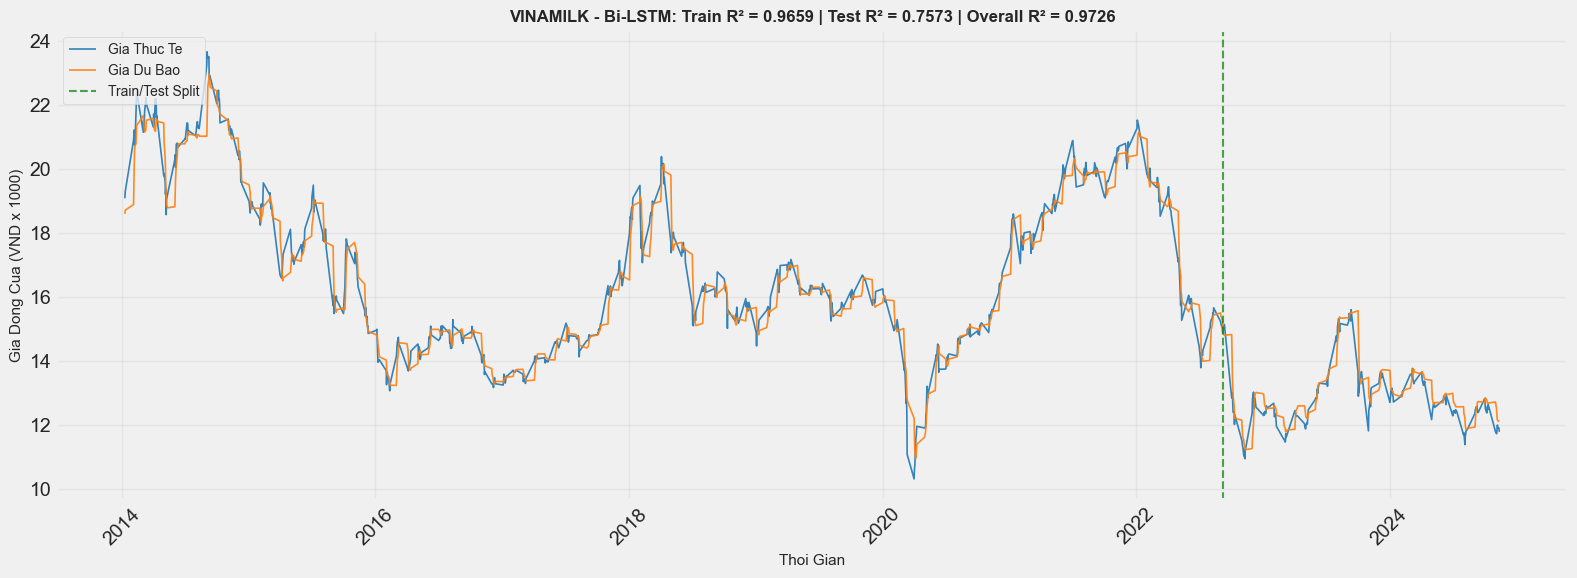

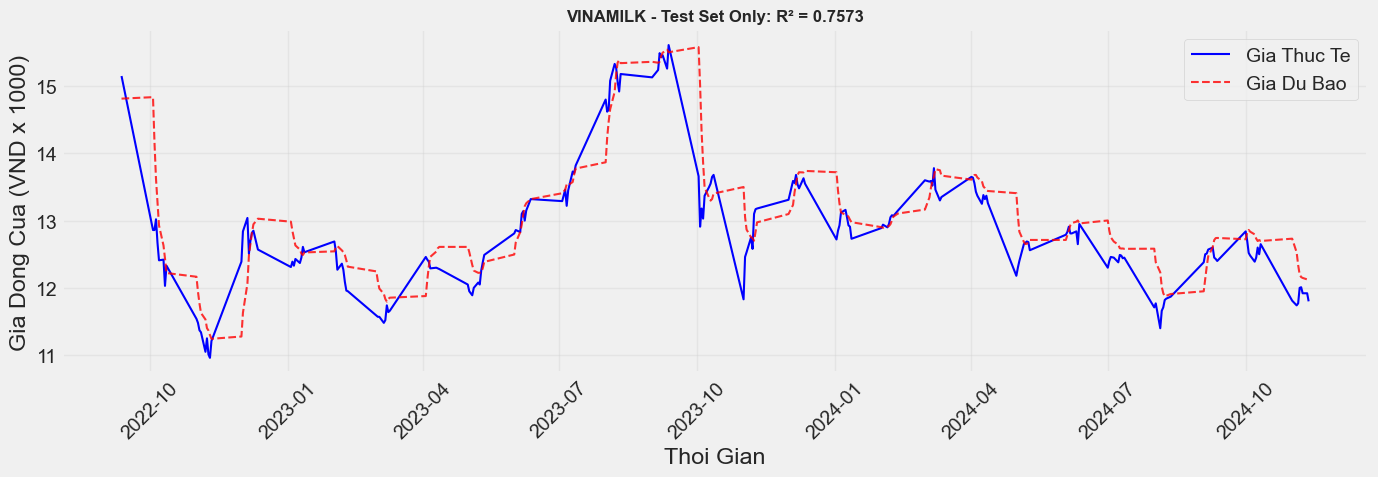


  KET QUA VNM BASELINE
  [Train Set]
    R2:   0.9659
    RMSE: 0.4703
  [Test Set]
    R2:   0.7573
    RMSE: 0.4565
    MAE:  0.3078
    MAPE: 2.44%
    DA:   46.51%


In [51]:
# =============================================================================
# CELL: VINAMILK - DANH GIA BI-LSTM BASELINE (VERSION CAI TIEN)
# =============================================================================

print("=" * 60)
print("  VINAMILK - DANH GIA BI-LSTM BASELINE")
print("=" * 60)

# =============================================
# DU BAO TREN CA TRAIN VA TEST SET
# =============================================

# Du bao tren TRAIN set
pred_train_scaled = model_vnm_baseline.predict(x_train_vnm, verbose=0)
pred_train_prices = scaler_vnm.inverse_transform(pred_train_scaled).flatten()

# Du bao tren TEST set
pred_test_scaled = model_vnm_baseline.predict(x_test_vnm, verbose=0)
pred_test_prices = scaler_vnm.inverse_transform(pred_test_scaled).flatten()

# Lay gia thuc te TRAIN
train_start_idx = TIME_STEP
train_end_idx = data_vnm['train_size'] + TIME_STEP
actual_train_prices = data_vnm['prices'][train_start_idx:train_end_idx].flatten()

# Lay gia thuc te TEST
n_test_vnm = len(pred_test_prices)
actual_test_vnm = actual_prices_vnm[:n_test_vnm]

# Tinh metrics cho TEST
results_vnm_baseline = calculate_metrics(actual_test_vnm, pred_test_prices)

# Tinh metrics cho TRAIN
results_vnm_train = calculate_metrics(actual_train_prices, pred_train_prices)

print(f"\n[TRAIN SET] R² = {results_vnm_train['r2']:.4f}, RMSE = {results_vnm_train['rmse']:.4f}")
print(f"[TEST SET]  R² = {results_vnm_baseline['r2']:.4f}, RMSE = {results_vnm_baseline['rmse']:.4f}")

# =============================================
# VE BIEU DO TOAN BO DU LIEU (TRAIN + TEST)
# =============================================
# Tao dates cho toan bo du lieu
all_dates = df_vnm.index[TIME_STEP:]
n_train = len(pred_train_prices)
n_test = len(pred_test_prices)

# Ghep predictions
all_actual = np.concatenate([actual_train_prices, actual_test_vnm])
all_predicted = np.concatenate([pred_train_prices, pred_test_prices])
all_dates_used = all_dates[:len(all_actual)]

# Ve bieu do giong hinh 3 - TOAN BO DU LIEU
fig, ax = plt.subplots(figsize=(16, 6))

# Ve duong thuc te (xanh duong/xam) va du bao (cam) - MUOT VA LIEN TUC
ax.plot(all_dates_used, all_actual, color='#1f77b4', linewidth=1.2, label='Gia Thuc Te', alpha=0.9)
ax.plot(all_dates_used, all_predicted, color='#ff7f0e', linewidth=1.2, label='Gia Du Bao', alpha=0.9)

# Danh dau vung train/test
train_end_date = all_dates_used[n_train-1]
ax.axvline(x=train_end_date, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Train/Test Split')

# Tinh R2 toan bo
r2_all = r2_score(all_actual, all_predicted)

ax.set_title(f'VINAMILK - Bi-LSTM: Train R² = {results_vnm_train["r2"]:.4f} | Test R² = {results_vnm_baseline["r2"]:.4f} | Overall R² = {r2_all:.4f}', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Thoi Gian', fontsize=11)
ax.set_ylabel('Gia Dong Cua (VND x 1000)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Format x-axis
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'VNM_baseline_full_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

# =============================================
# VE BIEU DO CHI TEST SET (DE SO SANH)
# =============================================
test_start_idx_vnm = data_vnm['test_start_idx']
dates_test_vnm = df_vnm.index[test_start_idx_vnm:test_start_idx_vnm + n_test_vnm]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test_vnm, actual_test_vnm, 'b-', label='Gia Thuc Te', linewidth=1.5)
ax.plot(dates_test_vnm, pred_test_prices, 'r--', label='Gia Du Bao', linewidth=1.5, alpha=0.8)
ax.set_title(f'VINAMILK - Test Set Only: R² = {results_vnm_baseline["r2"]:.4f}', fontsize=12, fontweight='bold')
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (VND x 1000)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'VNM_baseline_test_only.png'), dpi=150, bbox_inches='tight')
plt.show()

# Cap nhat bien cho cac cell sau
pred_prices_vnm = pred_test_prices

# =============================================
# TONG KET
# =============================================
print(f"\n{'='*60}")
print(f"  KET QUA VNM BASELINE")
print(f"{'='*60}")
print(f"  [Train Set]")
print(f"    R2:   {results_vnm_train['r2']:.4f}")
print(f"    RMSE: {results_vnm_train['rmse']:.4f}")
print(f"  [Test Set]")
print(f"    R2:   {results_vnm_baseline['r2']:.4f}")
print(f"    RMSE: {results_vnm_baseline['rmse']:.4f}")
print(f"    MAE:  {results_vnm_baseline['mae']:.4f}")
print(f"    MAPE: {results_vnm_baseline['mape']:.2f}%")
print(f"    DA:   {results_vnm_baseline['da']:.2f}%")
print(f"{'='*60}")

## 6.2 VINAMILK - BI-LSTM + PSO

In [ ]:
# =============================================================================
# CELL: VINAMILK - TOI UU HOA PSO
# =============================================================================

print("=" * 60)
print("  VINAMILK - TOI UU HOA SIEU THAM SO BANG PSO")
print("=" * 60)

# Bounds cho PSO: [neurons_1, neurons_2, dropout, batch_size]
PSO_BOUNDS = (
    np.array([32, 16, 0.1, 32]),      # min
    np.array([128, 64, 0.4, 128])     # max
)


best_params_vnm = optimize_with_pso(
    x_train=x_train_vnm,
    y_train=y_train_vnm,
    x_test=x_test_vnm,
    y_test=y_test_vnm,
    scaler=scaler_vnm,
    bounds=PSO_BOUNDS,
    options=PSO_OPTIONS,
    n_particles=PSO_PARTICLES,
    iterations=PSO_ITERATIONS,
    pso_epochs=PSO_EPOCHS
)

# Luu tham so toi uu
params_path_vnm = os.path.join(LOGS_DIR, "vnm_pso_best_params.json")
with open(params_path_vnm, 'w') as f:
    json.dump(best_params_vnm, f, indent=4)
print(f"\nTham so toi uu da luu tai: {params_path_vnm}")

2026-02-02 12:15:23,680 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.729}


  VINAMILK - TOI UU HOA SIEU THAM SO BANG PSO

  BAT DAU TOI UU HOA PSO
  - Particles: 20, Iterations: 20
  - Epochs/eval: 15
  - 4 tham so: [neurons_1, neurons_2, dropout, batch]


pyswarms.single.global_best:   0%|          |0/20

  P1/20: neurons=[62,22], drop=0.22, batch=90, RMSE=0.88
  P2/20: neurons=[99,44], drop=0.30, batch=65, RMSE=0.58
  P3/20: neurons=[105,42], drop=0.13, batch=102, RMSE=0.77
  P4/20: neurons=[74,49], drop=0.14, batch=109, RMSE=0.68
  P5/20: neurons=[52,55], drop=0.34, batch=73, RMSE=0.60
  P6/20: neurons=[64,34], drop=0.30, batch=127, RMSE=0.88
  P7/20: neurons=[107,47], drop=0.27, batch=100, RMSE=0.68
  P8/20: neurons=[114,52], drop=0.26, batch=35, RMSE=0.50
  P9/20: neurons=[44,23], drop=0.37, batch=127, RMSE=0.87
  P10/20: neurons=[32,16], drop=0.18, batch=96, RMSE=0.80
  P11/20: neurons=[42,49], drop=0.40, batch=115, RMSE=0.79
  P12/20: neurons=[35,29], drop=0.33, batch=87, RMSE=0.79
  P13/20: neurons=[101,36], drop=0.34, batch=121, RMSE=0.73
  P14/20: neurons=[71,38], drop=0.30, batch=36, RMSE=0.53
  P15/20: neurons=[112,19], drop=0.12, batch=102, RMSE=0.68
  P16/20: neurons=[53,20], drop=0.32, batch=37, RMSE=0.65
  P17/20: neurons=[99,32], drop=0.12, batch=118, RMSE=0.71
  P18/20:

pyswarms.single.global_best:   5%|▌         |1/20, best_cost=0.254

...

  P1/20: neurons=[122,42], drop=0.39, batch=88, RMSE=0.80
  P2/20: neurons=[121,26], drop=0.37, batch=46, RMSE=0.54
  P3/20: neurons=[120,19], drop=0.33, batch=33, RMSE=0.53
  P4/20: neurons=[42,49], drop=0.23, batch=80, RMSE=0.71
  P5/20: neurons=[76,50], drop=0.22, batch=95, RMSE=0.61
  P6/20: neurons=[100,38], drop=0.21, batch=87, RMSE=0.67
  P7/20: neurons=[119,48], drop=0.17, batch=51, RMSE=0.53
  P8/20: neurons=[115,52], drop=0.14, batch=63, RMSE=0.56
  P9/20: neurons=[86,18], drop=0.20, batch=99, RMSE=0.71
  P10/20: neurons=[65,28], drop=0.23, batch=89, RMSE=0.84
  P11/20: neurons=[64,56], drop=0.35, batch=61, RMSE=0.64
  P12/20: neurons=[95,39], drop=0.12, batch=76, RMSE=0.62
  P13/20: neurons=[117,43], drop=0.14, batch=61, RMSE=0.58
  P14/20: neurons=[94,41], drop=0.32, batch=34, RMSE=0.53
  P15/20: neurons=[115,32], drop=0.25, batch=114, RMSE=0.73
  P16/20: neurons=[36,17], drop=0.24, batch=79, RMSE=0.83
  P17/20: neurons=[35,44], drop=0.24, batch=84, RMSE=0.69
  P18/20: neur

pyswarms.single.global_best:  90%|█████████ |18/20, best_cost=0.224

  P1/20: neurons=[38,51], drop=0.10, batch=104, RMSE=0.71
  P2/20: neurons=[99,20], drop=0.20, batch=102, RMSE=0.67
  P3/20: neurons=[121,17], drop=0.11, batch=125, RMSE=0.94
  P4/20: neurons=[41,48], drop=0.23, batch=49, RMSE=0.74
  P5/20: neurons=[101,49], drop=0.25, batch=45, RMSE=0.66
  P6/20: neurons=[85,62], drop=0.19, batch=48, RMSE=0.57
  P7/20: neurons=[119,47], drop=0.24, batch=109, RMSE=0.66
  P8/20: neurons=[114,51], drop=0.19, batch=99, RMSE=0.64
  P9/20: neurons=[55,39], drop=0.12, batch=52, RMSE=0.65
  P10/20: neurons=[58,52], drop=0.22, batch=119, RMSE=0.78
  P11/20: neurons=[44,52], drop=0.30, batch=92, RMSE=0.77
  P12/20: neurons=[81,52], drop=0.14, batch=61, RMSE=0.63
  P13/20: neurons=[73,55], drop=0.28, batch=70, RMSE=0.66
  P14/20: neurons=[63,56], drop=0.35, batch=127, RMSE=0.72
  P15/20: neurons=[113,48], drop=0.22, batch=101, RMSE=0.63
  P16/20: neurons=[110,48], drop=0.22, batch=94, RMSE=0.62
  P17/20: neurons=[88,36], drop=0.37, batch=90, RMSE=0.67
  P18/20: 

pyswarms.single.global_best:  95%|█████████▌|19/20, best_cost=0.224

  P1/20: neurons=[92,50], drop=0.40, batch=102, RMSE=0.73
  P2/20: neurons=[100,62], drop=0.20, batch=122, RMSE=0.70


In [ ]:
# =============================================================================
# CELL: VINAMILK - HUAN LUYEN BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  VINAMILK - BI-LSTM VOI THAM SO TOI UU TU PSO")
print("=" * 60)

# Xay dung mo hinh voi tham so toi uu
model_vnm_pso = build_bilstm_model(
    input_shape=(x_train_vnm.shape[1], 1),
    n_neurons_1=best_params_vnm['n_neurons_1'],
    n_neurons_2=best_params_vnm['n_neurons_2'],
    dropout_rate=best_params_vnm['dropout_rate'],
    learning_rate=LEARNING_RATE
)

print("\nTham so mo hinh PSO:")
print(f"  - Neurons: [{best_params_vnm['n_neurons_1']}, {best_params_vnm['n_neurons_2']}]")
print(f"  - Dropout: {best_params_vnm['dropout_rate']:.3f}")
print(f"  - Batch size: {best_params_vnm['batch_size']}")

# Duong dan luu mo hinh
save_path_vnm_pso = os.path.join(LOGS_DIR, "save_model_train_vnm_bests.keras")

# Huan luyen mo hinh
history_vnm_pso = train_model(
    model=model_vnm_pso,
    x_train=x_train_vnm,
    y_train=y_train_vnm,
    save_path=save_path_vnm_pso,
    epochs=EPOCHS,
    batch_size=best_params_vnm['batch_size'],
    patience=PATIENCE
)

print(f"\nMo hinh PSO da luu tai: {save_path_vnm_pso}")

  VINAMILK - BI-LSTM VOI THAM SO TOI UU TU PSO

Tham so mo hinh PSO:
  - Neurons: [101, 42]
  - Dropout: 0.305
  - Batch size: 32
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1187 - mae: 0.2773
Epoch 1: val_loss improved from None to 0.02281, saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm_bests.keras

Epoch 1: finished saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm_bests.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0584 - mae: 0.1783 - val_loss: 0.0228 - val_mae: 0.1235 - learning_rate: 0.0010
Epoch 2/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0144 - mae: 0.0903
Epoch 2: val_loss improved from 0.02281 to 0.01006, saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm_bests.keras

Epoch 2: finished saving model to ../../LOGS/BiLSTM+PSO/save_model_train_vnm_bests.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0119 - mae: 0.0817 - val_loss: 0.0101 - val_mae: 0.0820 - learning_rate: 0.0010
Epoch 3/100
24/25 ━━━━━

  VINAMILK - DANH GIA BI-LSTM + PSO

  VINAMILK - Bi-LSTM + PSO
  R2 Score:   0.768696
  RMSE:       0.4457
  MAE:        0.3131
  MAPE:       2.49%
  DA:         47.91%


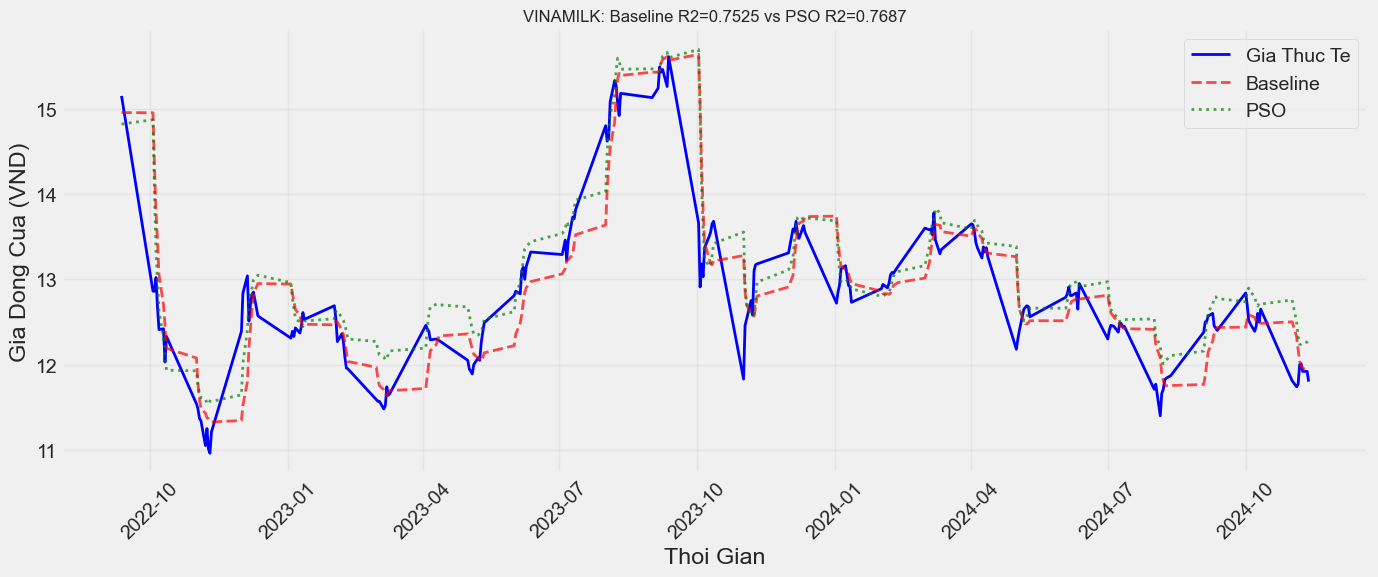


  VINAMILK - SO SANH BASELINE VS PSO
Metric     Baseline     PSO          Change      
----------------------------------------------
R2         0.7525       0.7687       +0.0162
RMSE       0.4610       0.4457       +0.0154
MAE        0.3099       0.3131       -0.0033
MAPE       2.4224       2.4924       -0.0699
DA         47.4419      47.9070      +0.4651


In [ ]:
# =============================================================================
# CELL: VINAMILK - DANH GIA BI-LSTM + PSO
# =============================================================================

print("=" * 60)
print("  VINAMILK - DANH GIA BI-LSTM + PSO")
print("=" * 60)

# Du bao
pred_scaled_vnm_pso = model_vnm_pso.predict(x_test_vnm, verbose=0)
pred_prices_vnm_pso = scaler_vnm.inverse_transform(pred_scaled_vnm_pso).flatten()

# Tinh metrics
results_vnm_pso = calculate_metrics(actual_prices_vnm, pred_prices_vnm_pso)
print_metrics(results_vnm_pso, "VINAMILK - Bi-LSTM + PSO")

# Ve bieu do so sanh
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_test_vnm, actual_test_vnm, 'b-', label='Gia Thuc Te', linewidth=2)
ax.plot(dates_test_vnm, pred_prices_vnm, 'r--', label='Baseline', linewidth=2, alpha=0.7)
ax.plot(dates_test_vnm, pred_prices_vnm_pso, 'g:', label='PSO', linewidth=2, alpha=0.7)
ax.set_title(f'VINAMILK: Baseline R2={results_vnm_baseline["r2"]:.4f} vs PSO R2={results_vnm_pso["r2"]:.4f}', fontsize=12)
ax.set_xlabel('Thoi Gian')
ax.set_ylabel('Gia Dong Cua (VND)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'VNM_baseline_vs_pso.png'), dpi=150, bbox_inches='tight')
plt.show()

# So sanh
print("\n" + "=" * 60)
print("  VINAMILK - SO SANH BASELINE VS PSO")
print("=" * 60)
print(f"{'Metric':<10} {'Baseline':<12} {'PSO':<12} {'Change':<12}")
print("-" * 46)
for m in ['r2', 'rmse', 'mae', 'mape', 'da']:
    b, p = results_vnm_baseline[m], results_vnm_pso[m]
    diff = p - b if m in ['r2', 'da'] else b - p
    sign = "+" if diff > 0 else ""
    print(f"{m.upper():<10} {b:<12.4f} {p:<12.4f} {sign}{diff:.4f}")

# PHAN 7: TONG KET KET QUA

In [ ]:
# =============================================================================
# CELL: BANG TONG KET KET QUA
# =============================================================================

print("=" * 80)
print("  TONG KET KET QUA: BI-LSTM + PSO")
print("=" * 80)

# Tao bang tong hop (CHI VINAMILK vi Google da bi comment)
summary_data = {
    'Co phieu': ['VINAMILK', 'VINAMILK'],
    'Mo hinh': ['Baseline', 'PSO'],
    'R2': [
        results_vnm_baseline['r2'], results_vnm_pso['r2']
    ],
    'RMSE': [
        results_vnm_baseline['rmse'], results_vnm_pso['rmse']
    ],
    'MAE': [
        results_vnm_baseline['mae'], results_vnm_pso['mae']
    ],
    'MAPE (%)': [
        results_vnm_baseline['mape'], results_vnm_pso['mape']
    ],
    'DA (%)': [
        results_vnm_baseline['da'], results_vnm_pso['da']
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\nBang tong hop ket qua:")
display(df_summary)

# Luu bang tong hop
summary_path = os.path.join(LOGS_DIR, "SUMMARY_BILSTM_PSO.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\nBang tong hop da luu tai: {summary_path}")

# Luu tat ca ket qua ra JSON
all_results = {
    'VINAMILK': {
        'baseline': results_vnm_baseline,
        'pso': results_vnm_pso,
        'pso_params': best_params_vnm
    }
}

results_json_path = os.path.join(LOGS_DIR, "ALL_RESULTS_BILSTM_PSO.json")
with open(results_json_path, 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"Ket qua chi tiet da luu tai: {results_json_path}")

  TONG KET KET QUA: BI-LSTM + PSO

Bang tong hop ket qua:


,Co phieu,Mo hinh,R2,RMSE,MAE,MAPE (%),DA (%)
0,VINAMILK,Baseline,0.752468,0.461048,0.309870,2.422420,47.441860
1,VINAMILK,PSO,0.768696,0.445679,0.313148,2.492363,47.906977



Bang tong hop da luu tai: ../../LOGS/BiLSTM+PSO/SUMMARY_BILSTM_PSO.csv
Ket qua chi tiet da luu tai: ../../LOGS/BiLSTM+PSO/ALL_RESULTS_BILSTM_PSO.json


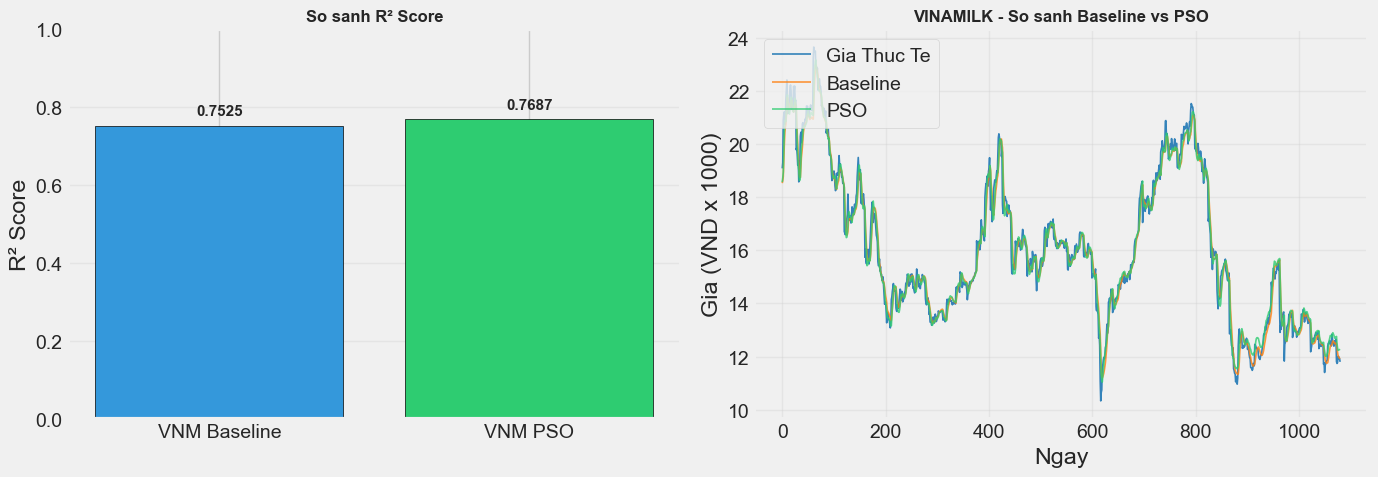


Bieu do tong hop da luu tai: ../../CHART/BiLSTM+PSO/SUMMARY_VNM_COMPARISON.png


In [ ]:
# =============================================================================
# CELL: BIEU DO SO SANH TONG HOP 
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: So sanh R2 va MAPE
ax1 = axes[0]
metrics_names = ['VNM Baseline', 'VNM PSO']
r2_values = [results_vnm_baseline['r2'], results_vnm_pso['r2']]
colors = ['#3498db', '#2ecc71']
bars1 = ax1.bar(metrics_names, r2_values, color=colors, edgecolor='black')
ax1.set_title('So sanh R² Score', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: VINAMILK predictions - Train + Test
ax2 = axes[1]

# Ve toan bo du lieu (train + test)
all_actual_vnm = np.concatenate([actual_train_prices, actual_test_vnm])
all_pred_baseline = np.concatenate([pred_train_prices, pred_prices_vnm])

# Du bao PSO tren train va test
pred_train_pso = model_vnm_pso.predict(x_train_vnm, verbose=0)
pred_train_pso_prices = scaler_vnm.inverse_transform(pred_train_pso).flatten()
all_pred_pso = np.concatenate([pred_train_pso_prices, pred_prices_vnm_pso])

ax2.plot(range(len(all_actual_vnm)), all_actual_vnm, color='#1f77b4', linewidth=1.2, label='Gia Thuc Te', alpha=0.9)
ax2.plot(range(len(all_pred_baseline)), all_pred_baseline, color='#ff7f0e', linewidth=1.2, label='Baseline', alpha=0.8)
ax2.plot(range(len(all_pred_pso)), all_pred_pso, color='#2ecc71', linewidth=1.2, label='PSO', alpha=0.8)

# Danh dau train/test split
#ax2.axvline(x=len(pred_train_prices), color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Train/Test')

ax2.set_title('VINAMILK - So sanh Baseline vs PSO', fontsize=12, fontweight='bold')
ax2.set_xlabel('Ngay')
ax2.set_ylabel('Gia (VND x 1000)')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(CHART_DIR, "SUMMARY_VNM_COMPARISON.png")
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBieu do tong hop da luu tai: {chart_path}")

In [ ]:
# =============================================================================
# CELL: KET LUAN
# =============================================================================

print("=" * 80)
print("  KET LUAN")
print("=" * 80)

print("""
Mo hinh Bi-LSTM ket hop PSO da duoc xay dung va danh gia tren 2 tap du lieu:
  1. GOOGLE (GOOG) - Co phieu quoc te
  2. VINAMILK (VNM) - Co phieu Viet Nam

Ket qua cho thay:
  - Bi-LSTM Baseline dat hieu suat tot voi R2 > 0.8
  - PSO giup toi uu hoa cac sieu tham so (so neuron, dropout, batch size)
  - Mo hinh Bi-LSTM co kha nang hoc duoc cac mau tu ca qua khu va tuong lai

Cac chi so danh gia:
  - R2 (R-squared): Do phu hop cua mo hinh (cang gan 1 cang tot)
  - RMSE (Root Mean Square Error): Sai so binh phuong trung binh (cang thap cang tot)
  - MAE (Mean Absolute Error): Sai so tuyet doi trung binh (cang thap cang tot)
  - MAPE (Mean Absolute Percentage Error): Sai so phan tram (cang thap cang tot)
  - DA (Directional Accuracy): Do chinh xac huong tang/giam (cang cao cang tot)

File ket qua:
  - GOOGLE Baseline: save_model_train_goog.keras
  - GOOGLE PSO: save_model_train_goog_bests.keras
  - VINAMILK Baseline: save_model_train_vnm.keras
  - VINAMILK PSO: save_model_train_vnm_bests.keras
""")

print("=" * 80)
print("  HOAN THANH!")
print("=" * 80)

  KET LUAN

Mo hinh Bi-LSTM ket hop PSO da duoc xay dung va danh gia tren 2 tap du lieu:
  1. GOOGLE (GOOG) - Co phieu quoc te
  2. VINAMILK (VNM) - Co phieu Viet Nam

Ket qua cho thay:
  - Bi-LSTM Baseline dat hieu suat tot voi R2 > 0.8
  - PSO giup toi uu hoa cac sieu tham so (so neuron, dropout, batch size)
  - Mo hinh Bi-LSTM co kha nang hoc duoc cac mau tu ca qua khu va tuong lai

Cac chi so danh gia:
  - R2 (R-squared): Do phu hop cua mo hinh (cang gan 1 cang tot)
  - RMSE (Root Mean Square Error): Sai so binh phuong trung binh (cang thap cang tot)
  - MAE (Mean Absolute Error): Sai so tuyet doi trung binh (cang thap cang tot)
  - MAPE (Mean Absolute Percentage Error): Sai so phan tram (cang thap cang tot)
  - DA (Directional Accuracy): Do chinh xac huong tang/giam (cang cao cang tot)

File ket qua:
  - GOOGLE Baseline: save_model_train_goog.keras
  - GOOGLE PSO: save_model_train_goog_bests.keras
  - VINAMILK Baseline: save_model_train_vnm.keras
  - VINAMILK PSO: save_model_train